In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Visualize quality assessment output of Hysets

In [4]:
filename = r"G:\Shared drives\Signatures -- large scale\baseflow\RAraki\out\caravan_datacheck\gages2_summary.csv"
hysets_qa = pd.read_csv(filename)
hysets_qa.set_index("gauge_id", inplace=True)

# Calculate some stats
hysets_qa["start_date"] = pd.to_datetime(hysets_qa["start_date"])
hysets_qa["end_date"] = pd.to_datetime(hysets_qa["end_date"])

hysets_qa["start_year"] = hysets_qa["start_date"].dt.year
hysets_qa["end_year"] = hysets_qa["end_date"].dt.year

hysets_qa["duration_yr"] = (
    hysets_qa["end_date"] - hysets_qa["start_date"]
).dt.days / 365

# hysets_qa = hysets_qa.join(attrs_cara["frac_snow"])

hysets_qa.head()

,start_date,end_date,nan_count,nan_fraction,subset_nan_fraction,Q95,start_year,end_year,duration_yr
gauge_id,,,,,,,,,
7145500,1980-01-01,2020-12-31,0.0,0.000000,0.0,0.843021,1980.0,2020.0,41.027397
12124000,1984-10-01,1987-03-23,14072.0,0.939637,0.0,3.821018,1984.0,1987.0,2.473973
10310407,2001-10-01,2020-12-31,7944.0,0.530449,0.0,2.094486,2001.0,2020.0,19.263014
8139500,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7305000,1980-01-01,2020-12-31,0.0,0.000000,0.0,0.238746,1980.0,2020.0,41.027397


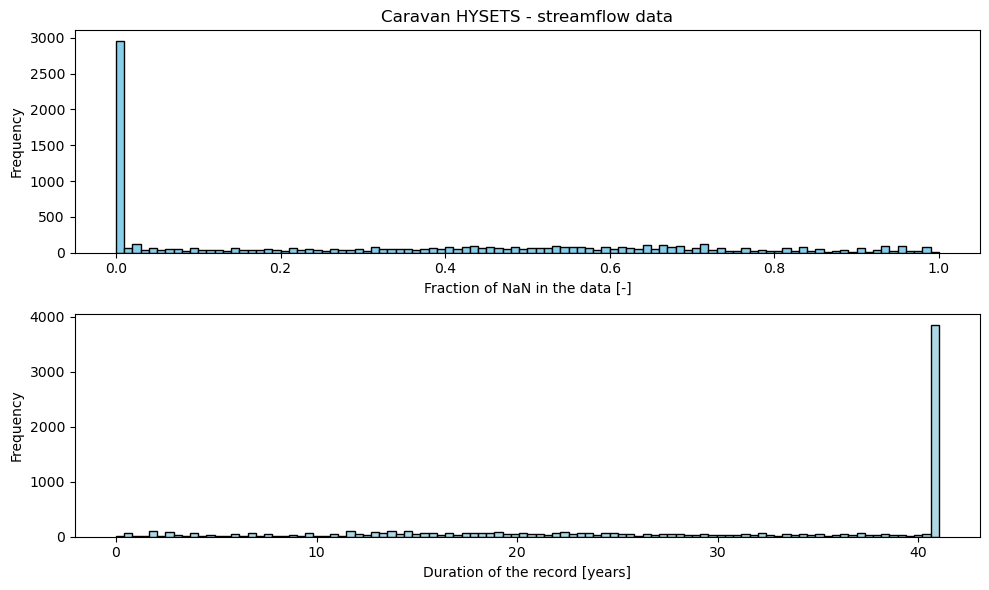

In [5]:
# Creating a 2x1 subplot layout
fig, ax = plt.subplots(2, 1, figsize=(10, 6))

# Plotting the start year histogram
ax[0].hist(hysets_qa["nan_fraction"], bins=100, color="skyblue", edgecolor="black")
ax[0].set_title("Caravan HYSETS - streamflow data")
ax[0].set_xlabel("Fraction of NaN in the data [-]")
ax[0].set_ylabel("Frequency")

# Plotting the end year histogram
ax[1].hist(hysets_qa["duration_yr"], bins=100, color="lightblue", edgecolor="black")
ax[1].set_xlabel("Duration of the record [years]")
ax[1].set_ylabel("Frequency")

# Adjust the layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()


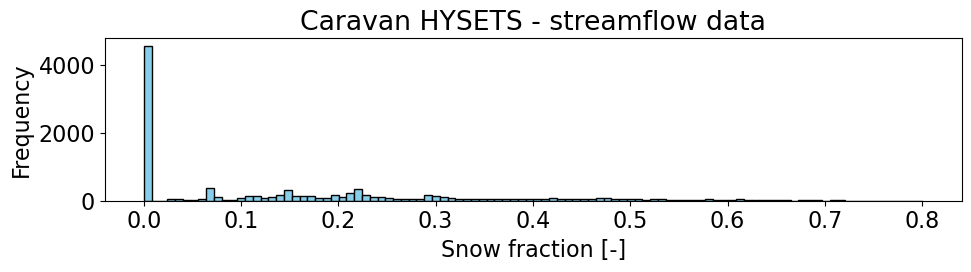

In [ ]:
# Creating a 2x1 subplot layout
fig, ax = plt.subplots(1, 1, figsize=(10, 3))

# Plotting the start year histogram
ax.hist(hysets_qa["frac_snow"], bins=100, color="skyblue", edgecolor="black")
ax.set_title("Caravan HYSETS - streamflow data")
ax.set_xlabel("Snow fraction [-]")
ax.set_ylabel("Frequency")

# Adjust the layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()


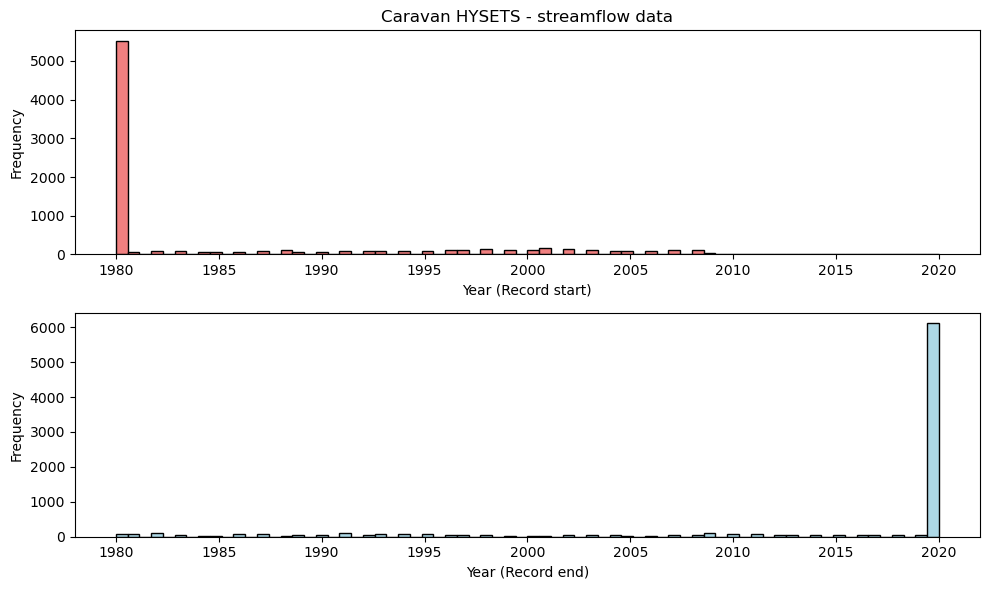

In [6]:
# Creating a 2x1 subplot layout
fig, ax = plt.subplots(2, 1, figsize=(10, 6))

# Plotting the start year histogram
ax[0].hist(hysets_qa["start_year"], bins=70, color="lightcoral", edgecolor="black")
ax[0].set_title("Caravan HYSETS - streamflow data")
ax[0].set_xlabel("Year (Record start)")
ax[0].set_ylabel("Frequency")

# Plotting the end year histogram
ax[1].hist(hysets_qa["end_year"], bins=70, color="lightblue", edgecolor="black")
ax[1].set_xlabel("Year (Record end)")
ax[1].set_ylabel("Frequency")

# Adjust the layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()


KeyError: 'gauge_lon'

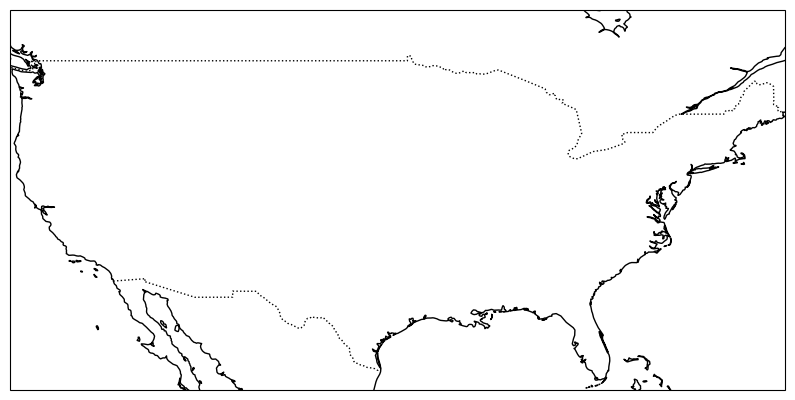

In [7]:
# Apply the filtering criteria


def plot_filtered_locations(df, criteria, label):
    good_data = df[df[criteria]]
    bad_data = df[~df[criteria]]

    # Set up the map
    fig = plt.figure(figsize=(10, 6))
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

    # Add map features
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle=":")

    # Set extent to CONUS
    ax.set_extent([-124.85, -66.95, 24.396308, 49.384358])

    # Plotting the filtered data
    ax.scatter(
        good_data["gauge_lon"],
        good_data["gauge_lat"],
        color="tab:blue",
        s=5,
        label=f"Accepted quality (n={len(good_data)})",
        alpha=0.5,
    )

    # Plotting the filtered data in red
    ax.scatter(
        bad_data["gauge_lon"],
        bad_data["gauge_lat"],
        color="tab:grey",
        s=5,
        label=f"Rejected (n={len(bad_data)})",
        alpha=0.5,
    )

    # Add a legend
    ax.legend()
    ax.set_title(label)

    # Show the plot
    plt.show()


nan_fraction_thresh = 0.9
hysets_qa["qf_nan_fraction"] = hysets_qa["nan_fraction"] < nan_fraction_thresh
plot_filtered_locations(
    hysets_qa, "qf_nan_fraction", f"Criteria: nan data < {nan_fraction_thresh * 100}%"
)

frac_snow_thresh = 0.2
hysets_qa["qf_frac_snow"] = hysets_qa["frac_snow"] < frac_snow_thresh
plot_filtered_locations(
    hysets_qa, "qf_frac_snow", f"Criteria: frac_snow < {frac_snow_thresh * 100}%"
)

subset_nan_fraction_thresh = 0.3
hysets_qa["qf_subset_nan_fraction"] = (
    hysets_qa["subset_nan_fraction"] < subset_nan_fraction_thresh
)
plot_filtered_locations(
    hysets_qa,
    "qf_subset_nan_fraction",
    f"Criteria: nan data < {subset_nan_fraction_thresh * 100}% for the period data available",
)

duration_thresh = 5
hysets_qa["qf_duration"] = hysets_qa["duration_yr"] > duration_thresh
plot_filtered_locations(
    hysets_qa, "qf_duration", f"Criteria: Duration > {duration_thresh}-yrs"
)

Q95_thresh = 1.0
hysets_qa["qf_Q95"] = hysets_qa["Q95"] > Q95_thresh
plot_filtered_locations(hysets_qa, "qf_Q95", f"Criteria: Q95 > {Q95_thresh} (mm/d)")

hysets_qa["qf_overall"] = (
    hysets_qa["qf_subset_nan_fraction"] & hysets_qa["qf_duration"]
)  #  & hysets_qa["qf_Q95"]
plot_filtered_locations(hysets_qa, "qf_overall", f"Overall criteria")

In [13]:
hysets_qa = hysets_qa.join(attrs_cara)
hysets_qa.columns

Index(['start_date', 'end_date', 'nan_count', 'nan_fraction',
       'subset_nan_fraction', 'Q95', 'start_year', 'end_year', 'duration_yr',
       'gauge_name', 'country', 'gauge_lat', 'gauge_lon', 'area', 'HUC',
       'qf_nan_fraction', 'qf_subset_nan_fraction', 'qf_duration', 'qf_Q95',
       'qf_overall', 'p_mean', 'pet_mean', 'aridity', 'frac_snow',
       'moisture_index', 'seasonality', 'high_prec_freq', 'high_prec_dur',
       'low_prec_freq', 'low_prec_dur'],
      dtype='object')

C:\Users\flipl\AppData\Local\Temp\ipykernel_14500\1394881863.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  count_data = df.groupby([f'{variable}_bin', 'qf_overall']).size().unstack(fill_value=0)
C:\Users\flipl\AppData\Local\Temp\ipykernel_14500\1394881863.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  count_data = df.groupby([f'{variable}_bin', 'qf_overall']).size().unstack(fill_value=0)
C:\Users\flipl\AppData\Local\Temp\ipykernel_14500\1394881863.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to ret

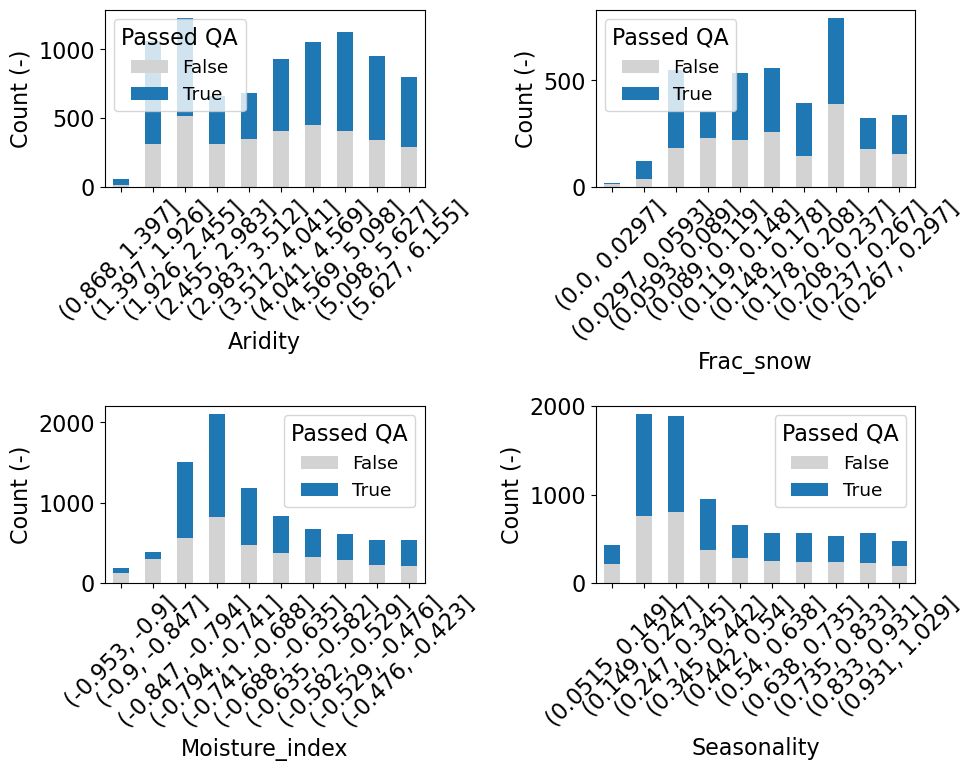

In [ ]:
def plot_boolean_counts(df, variable, bins=11, plot_color=["lightgrey", "tab:blue"]):
    """
    Plots boolean counts grouped by a specified environmental variable.

    Parameters:
    df (DataFrame): The input DataFrame.
    variable (str): The environmental variable to analyze.
    bins (int): Number of bins to use for the numerical variable.
    plot_color (list): List of colors for the plot.
    """
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))  # Set up a 2x2 subplot grid
    axes = axes.flatten()  # Flatten the 2D array of axes to make iteration easier

    for i, variable in enumerate(variables):
        # Binning the specified variable
        df[f"{variable}_bin"] = pd.cut(
            df[variable],
            bins=np.linspace(
                df[variable].quantile(0.0), df[variable].quantile(0.80), num=bins
            ),
        )

        # Grouping by the binned variable and qf_overall, then counting occurrences
        count_data = (
            df.groupby([f"{variable}_bin", "qf_overall"]).size().unstack(fill_value=0)
        )

        # Plotting on the appropriate subplot
        count_data.plot(kind="bar", stacked=True, color=plot_color, ax=axes[i])
        axes[i].set_xlabel(variable.capitalize())
        axes[i].set_ylabel("Count (-)")
        axes[i].tick_params(axis="x", rotation=45)
        axes[i].legend(title="Passed QA", fontsize="small")

    plt.tight_layout()
    plt.show()


variables = ["aridity", "frac_snow", "moisture_index", "seasonality"]
plot_boolean_counts(hysets_qa, variables)

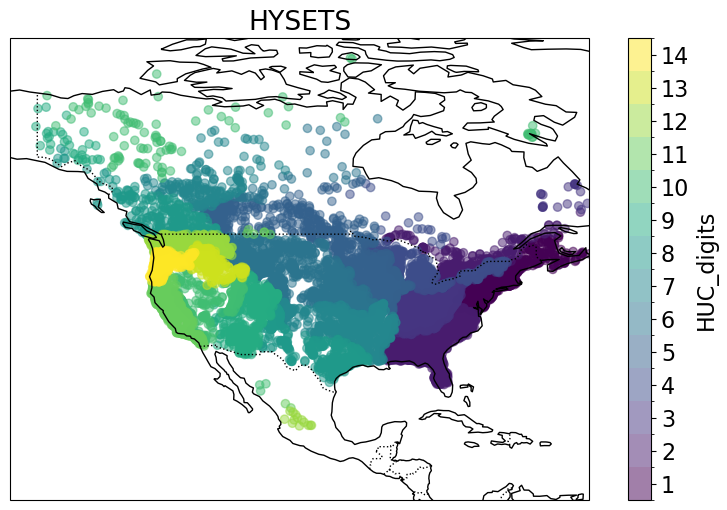

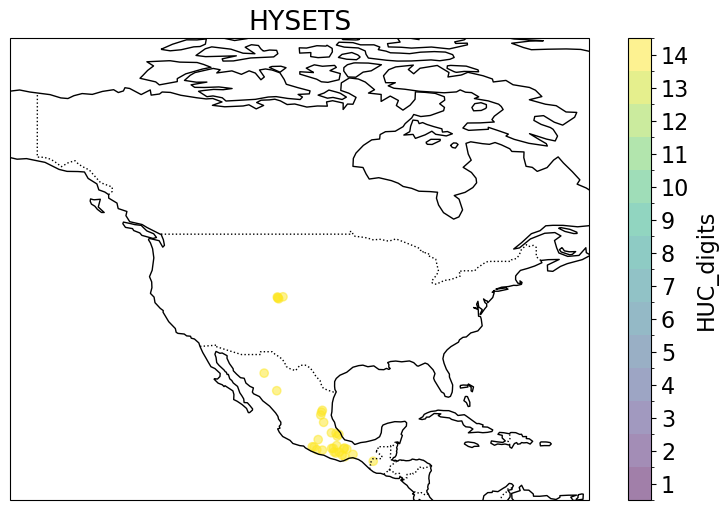

In [ ]:
def plot_map(df, varname):
    # Set up the map
    fig = plt.figure(figsize=(10, 6))
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

    # Add map features
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle=":")

    # Set extent to CONUS
    # ax.set_extent([-124.85, -66.95, 24.396308, 49.384358])
    ax.set_extent([-145, -60, 10, 74])  # Adjusted to include Alaska and Puerto Rico
    # ax.set_extent([-130, -60, 30, 75])
    # Plotting the filtered data

    # Define the boundaries for each color and normalize
    n_colors = 14  # Number of discrete colors
    cmap = plt.get_cmap("viridis", n_colors)  # Get a colormap with n discrete colors
    boundaries = np.arange(0.5, n_colors + 1.5, 1)  # Creates boundaries for 1 to 14
    norm = BoundaryNorm(boundaries, n_colors)

    scatter = ax.scatter(
        df["gauge_lon"], df["gauge_lat"], c=df[varname], alpha=0.5, cmap=cmap, norm=norm
    )
    cb = plt.colorbar(
        scatter,
        ax=ax,
        boundaries=boundaries,
        ticks=np.arange(1, 15),
        spacing="proportional",
    )
    # scatter=ax.scatter(df['gauge_lon'], df['gauge_lat'], c=df[varname], alpha=0.5)
    # cb = plt.colorbar(scatter, ax=ax)
    # Create a colorbar

    cb.set_label(varname)
    ax.set_title("HYSETS")

    # Show the plot
    plt.show()


from matplotlib.colors import ListedColormap, BoundaryNorm

attrs_geo["HUC_digits"] = attrs_geo["HUC"].astype(int)
plot_map(attrs_geo[attrs_geo["HUC_digits"] < 15].copy(), "HUC_digits")
plot_map(attrs_geo[attrs_geo["HUC_digits"] > 14].copy(), "HUC_digits")